# Potentiel évoqué auditif N100-P200 — visualisation\n\nCe notebook charge un enregistrement EEG (simulé ou réel, format OpenBCI/BrainFlow) et calcule le **potentiel évoqué moyen** aligné sur les tops TTL d'un paradigme auditif.\n\n**Format du fichier attendu :**\n- pas d'en-tête, délimiteur tabulation\n- colonnes 1 à 8 (index 0-based) : canaux EEG\n- colonne 13 (index 12) : TTL de stimulation (début de stimulation, pulse ~5 ms)\n\n**Étapes du pipeline :**\n1. chargement du CSV\n2. détection des tops TTL (colonne 13)\n3. filtrage passe-bande du signal EEG continu\n4. découpage en essais autour de chaque top, correction de ligne de base, rejet des essais bruités\n5. moyenne (grand average) ± erreur standard, et affichage avec repérage automatique du N100 et du P200"

In [51]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# ------------------------------------------------------------------
# Paramètres du fichier à charger
# ------------------------------------------------------------------
path = 'D:/DATA/Projets/M1_EEG_Project/data'
filename = 'openbci_simulated_N100P200_tab_sans_entete.csv'
# filename = 'BrainFlow-RAW_2026-09-08_10-47-23_2.csv'

delim = '\t'

FS = 250                 # Hz, fréquence d'échantillonnage
TTL_COL = 12    # colonne 13 (1-indexée) = index 12 (0-indexée)
EEG_COLS = list(range(1, 9))   # canaux EEG 1 à 8 = colonnes 1 à 8
CHANNEL_NAMES = [f'Ch{i+1}' for i in range(len(EEG_COLS))]

data = pd.read_csv(os.path.join(path, filename), delimiter=delim, header=None)
print(f"Données chargées : {data.shape[0]} échantillons x {data.shape[1]} colonnes "
      f"({data.shape[0] / FS:.1f} s à {FS} Hz)")
data.head()

Données chargées : 45000 échantillons x 24 colonnes (180.0 s à 250 Hz)


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.0,-17.747413,-25.946315,-29.694149,20.656261,-21.238881,-37.390881,-16.614024,6.208097,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788870e+09,0.0
1,1.0,-5.320242,-26.913345,-28.710460,7.814789,-10.244263,-13.677992,-12.554159,12.160760,-0.007372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788870e+09,0.0
2,2.0,-13.184347,-21.916459,-43.455898,-15.351702,-19.773141,-12.373082,-26.892914,14.417860,0.003098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788870e+09,0.0
3,3.0,-17.712326,-38.626182,-48.225096,-23.780764,-19.495026,-7.408116,-28.736636,23.446145,0.004252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788870e+09,0.0
4,4.0,-13.337042,-19.279613,-42.839703,-24.264699,5.446930,-0.470142,-49.566489,6.534868,0.003909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788870e+09,0.0


## 1. Détection des tops TTL (colonne 13)

Le canal TTL vaut 0 au repos et passe à 1 pendant ~5 ms au début de chaque stimulation auditive. On détecte les **fronts montants** (passage de 0 à 1).

Nombre de tops TTL détectés : 178
Intervalle inter-stimulus moyen : 995 ms


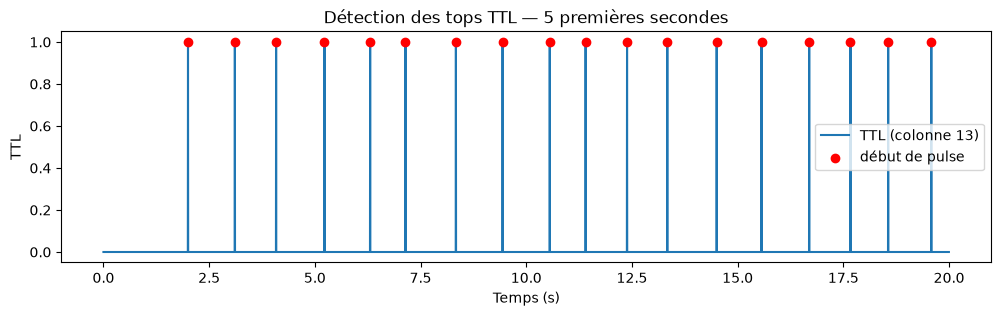

In [52]:
ttl = data[TTL_COL].to_numpy(dtype=float)

threshold = 0.5
above = ttl > threshold
onsets = np.where(above[1:] & ~above[:-1])[0] + 1

print(f"Nombre de tops TTL détectés : {len(onsets)}")
print(f"Intervalle inter-stimulus moyen : {np.mean(np.diff(onsets)) / FS * 1000:.0f} ms")

# zoom sur les premières secondes pour vérifier visuellement la détection
zoom = slice(0, 20 * FS)
plt.figure(figsize=(12, 3))
plt.plot(np.arange(zoom.stop) / FS, ttl[zoom], label='TTL (colonne 13)')
onsets_zoom = onsets[onsets < zoom.stop]
plt.scatter(onsets_zoom / FS, ttl[onsets_zoom], color='red', zorder=3, label='début de pulse')
plt.xlabel('Temps (s)')
plt.ylabel('TTL')
plt.title('Détection des tops TTL — 5 premières secondes')
plt.legend()
plt.show()

## 2. Filtrage du signal EEG

Filtre passe-bande (1-30 Hz, zero-phase) adapté à un ERP cortical N100-P200, et filtre coupe-bande (notch) à 50 Hz pour retirer le bruit secteur.

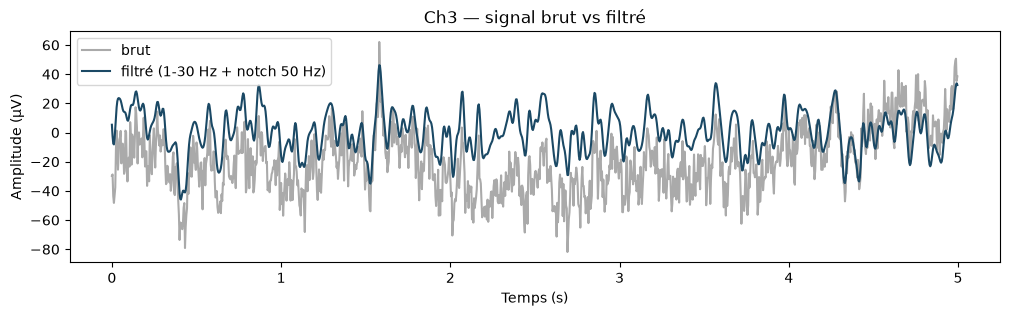

In [53]:
def bandpass_filter(sig, low=1.0, high=30.0, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)


def notch_filter(sig, freq=50.0, fs=FS, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)


# signal filtré pour chaque canal EEG
eeg_filtered = {
    name: notch_filter(bandpass_filter(data[col].to_numpy(dtype=float)))
    for name, col in zip(CHANNEL_NAMES, EEG_COLS)
}

# aperçu : brut vs filtré sur les 5 premières secondes, canal Ch3
zoom = slice(0, 5 * FS)
t_zoom = np.arange(zoom.stop) / FS
plt.figure(figsize=(12, 3))
plt.plot(t_zoom, data[EEG_COLS[2]].to_numpy(dtype=float)[zoom], color='#AAAAAA', label='brut')
plt.plot(t_zoom, eeg_filtered['Ch3'][zoom], color='#1B4965', label='filtré (1-30 Hz + notch 50 Hz)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (µV)')
plt.title('Ch3 — signal brut vs filtré')
plt.legend()
plt.show()

## 3. Découpage en essais (epoching) et rejet d'artefacts

Chaque essai ("epoch") couvre de -100 ms à +500 ms autour d'un top TTL. La ligne de base (-100 à 0 ms) est soustraite à chaque essai, puis les essais dont l'amplitude crête-à-crête dépasse un seuil sont rejetés (artefacts).

In [54]:
T_MIN, T_MAX = -0.10, 0.50       # fenêtre d'epoching (s) autour de chaque top
BASELINE = (-0.10, 0.0)          # fenêtre de correction de ligne de base (s)
REJECT_PTP_UV = 150.0            # amplitude crête-à-crête max tolérée par essai (µV)

n_pre = int(round(-T_MIN * FS))
n_post = int(round(T_MAX * FS))
time_epoch = (np.arange(n_pre + n_post) - n_pre) / FS


def epoch_signal(signal, onsets):
    epochs, kept = [], []
    for onset in onsets:
        start, end = onset - n_pre, onset + n_post
        if start < 0 or end > len(signal):
            continue  # essai tronqué en bord d'enregistrement -> ignoré
        epochs.append(signal[start:end])
        kept.append(onset)
    return np.array(epochs), np.array(kept)


def baseline_correct(epochs, times, baseline):
    mask = (times >= baseline[0]) & (times < baseline[1])
    return epochs - epochs[:, mask].mean(axis=1, keepdims=True)


results = {}   # nom du canal -> (epochs_clean, grand_avg, sem, n_total, n_kept)
for name in CHANNEL_NAMES:
    epochs, kept_onsets = epoch_signal(eeg_filtered[name], onsets)
    epochs = baseline_correct(epochs, time_epoch, BASELINE)

    ptp = epochs.max(axis=1) - epochs.min(axis=1)
    good = ptp <= REJECT_PTP_UV
    epochs_clean = epochs[good]

    grand_avg = epochs_clean.mean(axis=0)
    sem = epochs_clean.std(axis=0, ddof=1) / np.sqrt(epochs_clean.shape[0])
    results[name] = (epochs_clean, grand_avg, sem, epochs.shape[0], epochs_clean.shape[0])

    print(f"{name} : {epochs_clean.shape[0]}/{epochs.shape[0]} essais conservés après rejet d'artefacts")

Ch1 : 178/178 essais conservés après rejet d'artefacts
Ch2 : 178/178 essais conservés après rejet d'artefacts
Ch3 : 178/178 essais conservés après rejet d'artefacts
Ch4 : 178/178 essais conservés après rejet d'artefacts
Ch5 : 178/178 essais conservés après rejet d'artefacts
Ch6 : 178/178 essais conservés après rejet d'artefacts
Ch7 : 178/178 essais conservés après rejet d'artefacts
Ch8 : 178/178 essais conservés après rejet d'artefacts


## 4. Potentiel évoqué moyen — canal choisi

Essais individuels (gris), moyenne ± erreur standard (SEM), et repérage automatique des pics N100 (déflexion négative ~60-150 ms) et P200 (déflexion positive ~140-260 ms).

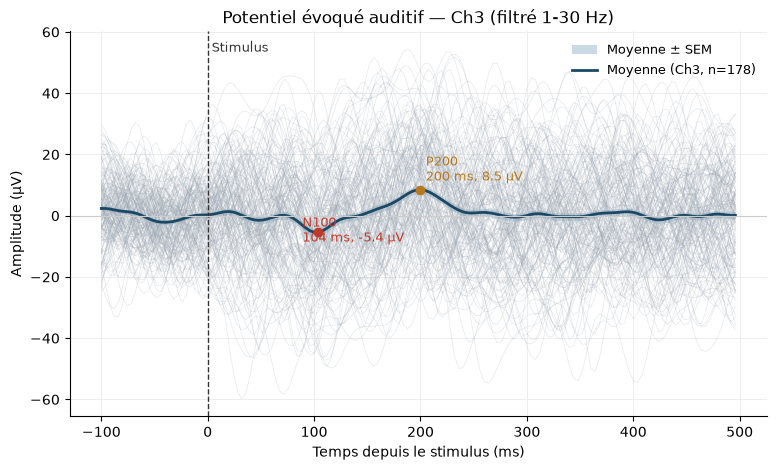

In [55]:
def find_peak(times, waveform, t_lo, t_hi, mode='min'):
    mask = (times >= t_lo) & (times <= t_hi)
    idx_local = np.argmin(waveform[mask]) if mode == 'min' else np.argmax(waveform[mask])
    idx_global = np.where(mask)[0][idx_local]
    return times[idx_global], waveform[idx_global]


CHANNEL_TO_PLOT = 'Ch3'
epochs_clean, grand_avg, sem, n_total, n_kept = results[CHANNEL_TO_PLOT]
t_ms = time_epoch * 1000

fig, ax = plt.subplots(figsize=(9, 5))

for ep in epochs_clean:
    ax.plot(t_ms, ep, color='#9AA5B1', linewidth=0.5, alpha=0.25)

ax.fill_between(t_ms, grand_avg - sem, grand_avg + sem, color='#2E6F95', alpha=0.25,
                 linewidth=0, label='Moyenne ± SEM')
ax.plot(t_ms, grand_avg, color='#1B4965', linewidth=2, label=f'Moyenne ({CHANNEL_TO_PLOT}, n={n_kept})')

ax.axvline(0, color='#333333', linestyle='--', linewidth=1)
ax.axhline(0, color='#CCCCCC', linewidth=0.8)
ax.text(0, ax.get_ylim()[1] * 0.95, ' Stimulus', color='#333333', fontsize=9, va='top')

t_n1, a_n1 = find_peak(time_epoch, grand_avg, 0.06, 0.15, mode='min')
ax.plot(t_n1 * 1000, a_n1, 'o', color='#C0392B', markersize=6)
ax.annotate(f'N100\n{t_n1*1000:.0f} ms, {a_n1:.1f} µV', xy=(t_n1 * 1000, a_n1),
            xytext=(t_n1 * 1000 - 15, a_n1 - 3), fontsize=9, color='#C0392B')

t_p2, a_p2 = find_peak(time_epoch, grand_avg, 0.14, 0.26, mode='max')
ax.plot(t_p2 * 1000, a_p2, 'o', color='#B7791F', markersize=6)
ax.annotate(f'P200\n{t_p2*1000:.0f} ms, {a_p2:.1f} µV', xy=(t_p2 * 1000, a_p2),
            xytext=(t_p2 * 1000 + 5, a_p2 + 3), fontsize=9, color='#B7791F')

ax.set_xlabel("Temps depuis le stimulus (ms)")
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Potentiel évoqué auditif — {CHANNEL_TO_PLOT} (filtré 1-30 Hz)')
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, color='#EEEEEE', linewidth=0.7)
plt.show()

## 5. Vue d'ensemble sur les 8 canaux

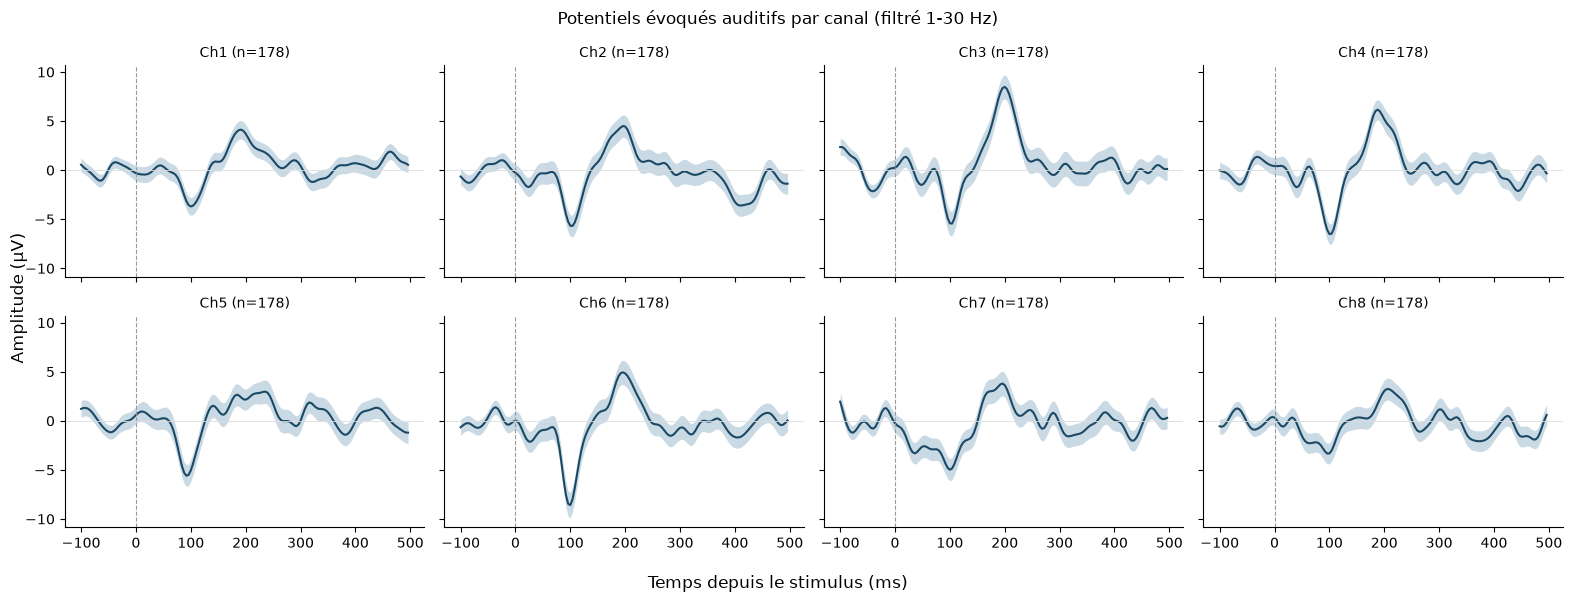

In [56]:
n_cols = 4
n_rows = int(np.ceil(len(CHANNEL_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, name in enumerate(CHANNEL_NAMES):
    ax = axes[i]
    _, grand_avg, sem, _, n_kept = results[name]
    ax.fill_between(t_ms, grand_avg - sem, grand_avg + sem, color='#2E6F95', alpha=0.25, linewidth=0)
    ax.plot(t_ms, grand_avg, color='#1B4965', linewidth=1.5)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='#DDDDDD', linewidth=0.6)
    ax.set_title(f'{name} (n={n_kept})', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(len(CHANNEL_NAMES), len(axes)):
    axes[j].axis('off')

fig.supxlabel("Temps depuis le stimulus (ms)")
fig.supylabel('Amplitude (µV)')
fig.suptitle('Potentiels évoqués auditifs par canal (filtré 1-30 Hz)')
fig.tight_layout()
plt.show()